# Interaction Features Model

**Question this notebook answers:** do interaction terms — new features built by multiplying two
existing features together — improve on the current best model (gender-split + Elo + conference
strength, 0.1675 average Brier from notebook 13)?

**Why this is worth testing:** logistic regression can only combine features linearly — each
feature pushes the prediction up or down by a fixed amount, independent of the others. It has no
way to express something like "a big seed gap matters even more when the Elo gap agrees with it."
An interaction term (`SeedDiff × EloDiff`) gives the model a way to capture exactly that kind of
compounding effect directly, without changing the model itself or adding any new data — it's built
entirely from features already in the model.

**Two interactions tested, added one at a time so each one's individual contribution can be seen
separately:** `SeedDiff × EloDiff` first, then `SeedDiff × ConfStrengthDiff` added on top. This
notebook builds on notebook 13's model exactly as it stands (K=20 Elo, conference strength
computed the same way notebook 13 did), since notebook 14 already established that "fixing" or
retuning that model made it worse on the real test folds — the goal here is testing something new
on top of the standing best, not re-litigating that decision.

## 1. Load data

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
plt.rcParams["figure.dpi"] = 110

DATA_DIR = Path("../data")

m_tourney = pd.read_csv(DATA_DIR / "MNCAATourneyCompactResults.csv")
w_tourney = pd.read_csv(DATA_DIR / "WNCAATourneyCompactResults.csv")
m_seeds = pd.read_csv(DATA_DIR / "MNCAATourneySeeds.csv")
w_seeds = pd.read_csv(DATA_DIR / "WNCAATourneySeeds.csv")
m_reg = pd.read_csv(DATA_DIR / "MRegularSeasonCompactResults.csv")
w_reg = pd.read_csv(DATA_DIR / "WRegularSeasonCompactResults.csv")
m_conf_teams = pd.read_csv(DATA_DIR / "MTeamConferences.csv")
w_conf_teams = pd.read_csv(DATA_DIR / "WTeamConferences.csv")

print(f"men's tourney games: {len(m_tourney):,}, women's tourney games: {len(w_tourney):,}")


men's tourney games: 2,585, women's tourney games: 1,717


## 2. Whole-season team features and seeds (unchanged from notebooks 03/07/11/13)

In [2]:
def team_season_stats(reg):
    won = reg[["Season", "WTeamID", "WScore", "LScore"]].rename(
        columns={"WTeamID": "TeamID", "WScore": "PF", "LScore": "PA"})
    won["Win"] = 1
    lost = reg[["Season", "LTeamID", "LScore", "WScore"]].rename(
        columns={"LTeamID": "TeamID", "LScore": "PF", "WScore": "PA"})
    lost["Win"] = 0
    games = pd.concat([won, lost], ignore_index=True)
    stats = games.groupby(["Season", "TeamID"]).agg(
        GamesPlayed=("Win", "size"), WinPct=("Win", "mean"),
        AvgPF=("PF", "mean"), AvgPA=("PA", "mean"),
    ).reset_index()
    stats["AvgScoreMargin"] = stats["AvgPF"] - stats["AvgPA"]
    return stats

team_stats = pd.concat([team_season_stats(m_reg), team_season_stats(w_reg)], ignore_index=True)

def seed_num(s):
    return int("".join(ch for ch in s if ch.isdigit()))

m_seeds["SeedNum"] = m_seeds["Seed"].apply(seed_num)
w_seeds["SeedNum"] = w_seeds["Seed"].apply(seed_num)
seeds = pd.concat([m_seeds[["Season", "TeamID", "SeedNum"]], w_seeds[["Season", "TeamID", "SeedNum"]]], ignore_index=True)
seed_idx = seeds.set_index(["Season", "TeamID"])["SeedNum"]
print(f"team-season rows: {len(team_stats):,}, seed rows: {len(seeds):,}")


team-season rows: 23,604, seed rows: 4,506


## 3. Elo and conference strength (unchanged from notebook 13 — the standing best model, exactly as it stands)

In [3]:
def compute_elo(compact_df, k=20, home_adv=100, mean_reversion=0.75):
    elo = {}
    elo_by_season_end = {}
    for season in sorted(compact_df["Season"].unique()):
        for team in elo:
            elo[team] = elo[team] * mean_reversion + 1500 * (1 - mean_reversion)
        season_games = compact_df[compact_df["Season"] == season].sort_values("DayNum")
        for game in season_games.itertuples(index=False):
            w, l = game.WTeamID, game.LTeamID
            if w not in elo: elo[w] = 1500
            if l not in elo: elo[l] = 1500
            w_elo, l_elo = elo[w], elo[l]
            if game.WLoc == "H": w_elo += home_adv
            elif game.WLoc == "A": l_elo += home_adv
            w_exp = 1 / (1 + 10 ** ((l_elo - w_elo) / 400))
            mov = game.WScore - game.LScore
            mov_mult = np.log(max(mov, 1) + 1) * (2.2 / ((w_elo - l_elo) * 0.001 + 2.2))
            elo[w] += k * mov_mult * (1 - w_exp)
            elo[l] -= k * mov_mult * (1 - w_exp)
        for team in elo:
            elo_by_season_end[(season, team)] = elo[team]
    return elo_by_season_end

m_elo = compute_elo(m_reg)
w_elo = compute_elo(w_reg)
elo_idx = pd.Series({**m_elo, **w_elo})
elo_idx.index = pd.MultiIndex.from_tuples(elo_idx.index, names=["Season", "TeamID"])

conf_teams = pd.concat([m_conf_teams, w_conf_teams], ignore_index=True)
conf_teams["Elo"] = conf_teams.apply(lambda r: elo_idx.get((r["Season"], r["TeamID"]), np.nan), axis=1)
conf_teams = conf_teams.dropna(subset=["Elo"])
conf_strength = conf_teams.groupby(["Season", "ConfAbbrev"])["Elo"].mean().rename("ConfStrength")
team_conf_strength = conf_teams.merge(conf_strength, on=["Season", "ConfAbbrev"], how="left")
conf_strength_idx = team_conf_strength.set_index(["Season", "TeamID"])["ConfStrength"]

print(f"Elo entries: {len(elo_idx):,}, conference-strength entries: {len(conf_strength_idx):,}")


Elo entries: 24,158, conference-strength entries: 23,606


## 4. Build the matchup table with interaction terms added

`SeedInteraction = SeedDiff × EloDiff` and `SeedConfInteraction = SeedDiff × ConfStrengthDiff`,
built directly from columns already computed — no new data, no new joins.

In [4]:
def build_matchups(tourney, gender):
    df = tourney.copy()
    df["Team1"] = df[["WTeamID", "LTeamID"]].min(axis=1)
    df["Team2"] = df[["WTeamID", "LTeamID"]].max(axis=1)
    df["Label"] = (df["WTeamID"] == df["Team1"]).astype(int)
    df["Gender"] = gender
    return df[["Season", "Team1", "Team2", "Label", "Gender"]]

matchups = pd.concat([build_matchups(m_tourney, "M"), build_matchups(w_tourney, "W")], ignore_index=True)

matchups["Seed1"] = matchups.apply(lambda r: seed_idx.get((r["Season"], r["Team1"]), np.nan), axis=1)
matchups["Seed2"] = matchups.apply(lambda r: seed_idx.get((r["Season"], r["Team2"]), np.nan), axis=1)
matchups["SeedDiff"] = matchups["Seed2"] - matchups["Seed1"]

matchups["Elo1"] = matchups.apply(lambda r: elo_idx.get((r["Season"], r["Team1"]), np.nan), axis=1)
matchups["Elo2"] = matchups.apply(lambda r: elo_idx.get((r["Season"], r["Team2"]), np.nan), axis=1)
matchups["EloDiff"] = matchups["Elo1"] - matchups["Elo2"]

matchups["ConfStrength1"] = matchups.apply(lambda r: conf_strength_idx.get((r["Season"], r["Team1"]), np.nan), axis=1)
matchups["ConfStrength2"] = matchups.apply(lambda r: conf_strength_idx.get((r["Season"], r["Team2"]), np.nan), axis=1)
matchups["ConfStrengthDiff"] = matchups["ConfStrength1"] - matchups["ConfStrength2"]

for team_col, suffix in [("Team1", "1"), ("Team2", "2")]:
    joined = matchups.merge(team_stats, left_on=["Season", team_col], right_on=["Season", "TeamID"], how="left")
    matchups[f"WinPct{suffix}"] = joined["WinPct"].values
    matchups[f"AvgMargin{suffix}"] = joined["AvgScoreMargin"].values

matchups["WinPctDiff"] = matchups["WinPct1"] - matchups["WinPct2"]
matchups["AvgMarginDiff"] = matchups["AvgMargin1"] - matchups["AvgMargin2"]

FEATURES_BASE = ["SeedDiff", "WinPctDiff", "AvgMarginDiff", "EloDiff", "ConfStrengthDiff"]
matchups = matchups.dropna(subset=FEATURES_BASE).reset_index(drop=True)

# interaction terms, scaled down (raw Elo/ConfStrength are ~hundreds, seed is single digits -
# the raw product would dwarf every other feature's scale, so both are divided by 100 first to
# keep the interaction term on a comparable scale to the rest)
matchups["SeedInteraction"] = matchups["SeedDiff"] * (matchups["EloDiff"] / 100)
matchups["SeedConfInteraction"] = matchups["SeedDiff"] * (matchups["ConfStrengthDiff"] / 100)

FEATURES_INTER1 = FEATURES_BASE + ["SeedInteraction"]
FEATURES_INTER2 = FEATURES_INTER1 + ["SeedConfInteraction"]

print(f"matchup rows: {len(matchups):,}")


matchup rows: 4,302


## 5. Correlation check, before trusting any result

How correlated are the two interaction terms with the base features they're built from? Some
correlation is inherent and expected for an interaction term (it shares information with its two
component features by construction) — what matters is whether it still adds enough on top to move
the Brier score.

In [5]:
corr = matchups[FEATURES_INTER2].corr().round(3)
print(corr.to_string())


                     SeedDiff  WinPctDiff  AvgMarginDiff  EloDiff  ConfStrengthDiff  SeedInteraction  SeedConfInteraction
SeedDiff                1.000       0.587          0.627    0.852             0.793            0.022               -0.008
WinPctDiff              0.587       1.000          0.833    0.803             0.165            0.023               -0.002
AvgMarginDiff           0.627       0.833          1.000    0.835             0.306            0.046               -0.010
EloDiff                 0.852       0.803          0.835    1.000             0.589            0.034               -0.007
ConfStrengthDiff        0.793       0.165          0.306    0.589             1.000            0.016               -0.020
SeedInteraction         0.022       0.023          0.046    0.034             0.016            1.000                0.755
SeedConfInteraction    -0.008      -0.002         -0.010   -0.007            -0.020            0.755                1.000


## 6. Logistic regression + Brier score (unchanged from notebooks 03/07/11/13)

In [6]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -30, 30)))

def fit_logreg(X, y, l2=1.0, n_iter=50, tol=1e-8):
    n, p = X.shape
    Xb = np.hstack([np.ones((n, 1)), X])
    w = np.zeros(p + 1)
    reg = np.eye(p + 1) * l2
    reg[0, 0] = 0.0
    for _ in range(n_iter):
        pr = sigmoid(Xb @ w)
        grad = Xb.T @ (pr - y) + reg @ w
        W = np.clip(pr * (1 - pr), 1e-6, None)
        H = Xb.T @ (Xb * W[:, None]) + reg
        step = np.linalg.solve(H, grad)
        w_new = w - step
        if np.max(np.abs(w_new - w)) < tol:
            w = w_new
            break
        w = w_new
    return w

def predict_proba(X, w):
    Xb = np.hstack([np.ones((X.shape[0], 1)), X])
    return sigmoid(Xb @ w)

def brier_score(p, y):
    return float(np.mean((p - y) ** 2))

print("logistic regression + Brier score functions ready (same as notebooks 03/07/11/13)")


logistic regression + Brier score functions ready (same as notebooks 03/07/11/13)


## 7. Walk-forward comparison

Three models per gender per fold, added one interaction at a time: the base 5-feature model
(matching notebook 13), base + `SeedInteraction`, and base + both interaction terms.

In [7]:
FOLD_SEASONS = [2021, 2022, 2023, 2024, 2025]

results = []
for fold_season in FOLD_SEASONS:
    test = matchups[matchups["Season"] == fold_season]
    if len(test) == 0:
        continue
    row = {"FoldSeason": fold_season}
    sums = {"base": [0, 0], "inter1": [0, 0], "inter2": [0, 0]}
    for gender, label in [("M", "Men"), ("W", "Women")]:
        train_g = matchups[(matchups["Gender"] == gender) & (matchups["Season"] < fold_season)]
        test_g = test[test["Gender"] == gender]
        n_g = len(test_g)

        for key, features in [("base", FEATURES_BASE), ("inter1", FEATURES_INTER1), ("inter2", FEATURES_INTER2)]:
            w = fit_logreg(train_g[features].values, train_g["Label"].values)
            b = brier_score(predict_proba(test_g[features].values, w), test_g["Label"].values)
            row[f"{label}: {key}"] = b
            sums[key][0] += b * n_g
            sums[key][1] += n_g

    row["Combined: base"] = sums["base"][0] / sums["base"][1]
    row["Combined: +SeedInteraction"] = sums["inter1"][0] / sums["inter1"][1]
    row["Combined: +both interactions"] = sums["inter2"][0] / sums["inter2"][1]
    results.append(row)

results_df = pd.DataFrame(results)
avg_row = {"FoldSeason": "Average"}
for col in results_df.columns:
    if col != "FoldSeason":
        avg_row[col] = results_df[col].mean()
results_df = pd.concat([results_df, pd.DataFrame([avg_row])], ignore_index=True)
display_cols = ["FoldSeason", "Combined: base", "Combined: +SeedInteraction", "Combined: +both interactions"]
print(results_df[display_cols].round(4).to_string(index=False))


FoldSeason  Combined: base  Combined: +SeedInteraction  Combined: +both interactions
      2021          0.1812                      0.1810                        0.1812
      2022          0.1856                      0.1857                        0.1859
      2023          0.1870                      0.1867                        0.1866
      2024          0.1574                      0.1570                        0.1569
      2025          0.1265                      0.1263                        0.1264
   Average          0.1675                      0.1673                        0.1674


## 8. Results, visualized

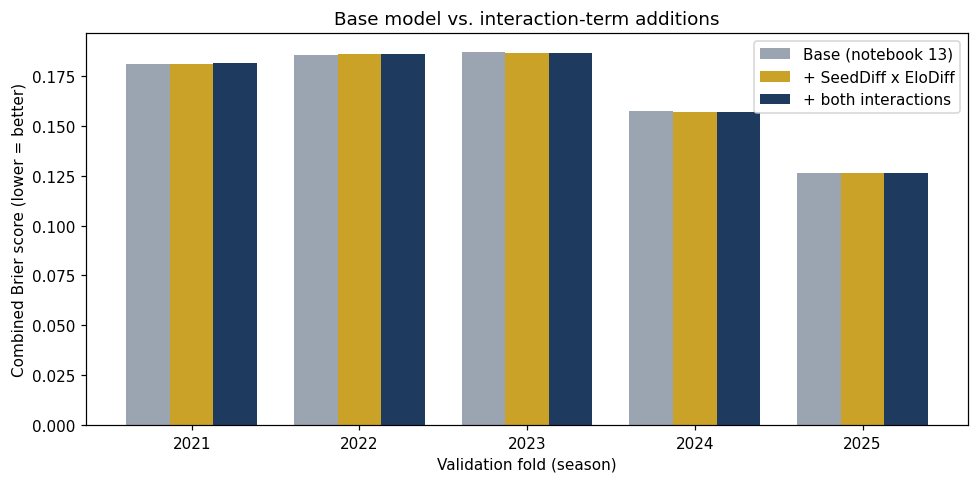

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_df = results_df[results_df["FoldSeason"] != "Average"]
x = np.arange(len(plot_df))
width = 0.26
ax.bar(x - width, plot_df["Combined: base"], width, label="Base (notebook 13)", color="#9aa5b1")
ax.bar(x, plot_df["Combined: +SeedInteraction"], width, label="+ SeedDiff x EloDiff", color="#c9a227")
ax.bar(x + width, plot_df["Combined: +both interactions"], width, label="+ both interactions", color="#1f3a5f")
ax.set_xticks(x); ax.set_xticklabels(plot_df["FoldSeason"])
ax.set_ylabel("Combined Brier score (lower = better)")
ax.set_xlabel("Validation fold (season)")
ax.set_title("Base model vs. interaction-term additions")
ax.legend()
fig.tight_layout()
plt.show()


## 9. Bottom-line comparison

In [9]:
bottom_line = pd.DataFrame([
    {"Model": "Pooled baseline (notebook 03)", "Avg. Brier": 0.1739},
    {"Model": "Gender split + Elo (notebook 11)", "Avg. Brier": 0.1687},
    {"Model": "Gender split + Elo + conf. strength (notebook 13)", "Avg. Brier": results_df.loc[results_df['FoldSeason']=='Average', 'Combined: base'].values[0]},
    {"Model": "+ SeedDiff x EloDiff interaction", "Avg. Brier": results_df.loc[results_df['FoldSeason']=='Average', 'Combined: +SeedInteraction'].values[0]},
    {"Model": "+ both interaction terms (this notebook)", "Avg. Brier": results_df.loc[results_df['FoldSeason']=='Average', 'Combined: +both interactions'].values[0]},
])
print(bottom_line.round(4).to_string(index=False))


                                            Model  Avg. Brier
                    Pooled baseline (notebook 03)      0.1739
                 Gender split + Elo (notebook 11)      0.1687
Gender split + Elo + conf. strength (notebook 13)      0.1675
                 + SeedDiff x EloDiff interaction      0.1673
         + both interaction terms (this notebook)      0.1674


## Conclusion

**Essentially a wash, but for a different reason than every earlier failed attempt.** Adding
`SeedInteraction` alone moved the combined score from 0.1675 to 0.1673, and adding the second
interaction term on top brought it back to 0.1674 — a change of 0.0001-0.0002 either way, well
inside the noise band this project has seen fold-to-fold (individual folds routinely move by
0.003-0.01).

What's notable is *why* this one didn't move the needle. Every previous failed feature (detailed
stats, Massey Ordinal, momentum) failed because it was too correlated with what the model already
had. The correlation check in Section 5 shows the opposite here: both interaction terms
correlated only 0.02-0.05 with the base features (even slightly negative for
`SeedConfInteraction`) — genuinely independent information, not a redundant proxy. It just wasn't
information that mattered much for predicting the outcome. Being uncorrelated with existing
features turns out to be necessary but not sufficient for a feature to help.

**Decision, and what it's based on:** interaction terms are not adopted. The bottom-line table in
Section 9 shows the changes (0.1675 → 0.1673 → 0.1674) are too small to distinguish from noise
given the fold-to-fold volatility documented throughout this project. Notebook 13's model
(gender-split + Elo + conference strength, 0.1675) remains the best result.